# CCGT+CCS NPV simulation

Run the CCGT+CCS electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_ccgt_ccs_npv,
)


In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_ccgt_ccs_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2315.132972,54.598866,6.170550,1.919173,...,94070000.0,1.174169e+07,6.170550e+06,9.699670e+07,1.525554e+06,-2.236450e+07,-7.366141e+08,25000000.0,-29.464563,-0.000029
1,1,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1956.599931,55.015181,6.145733,1.916457,...,94070000.0,1.183122e+07,6.145733e+06,3.901189e+07,2.828864e+06,3.425229e+07,-5.513861e+07,25000000.0,-2.205544,-0.000002
2,2,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2405.699774,44.768220,7.003360,1.930666,...,94070000.0,9.627574e+06,7.003360e+06,7.130715e+07,1.757978e+06,4.373943e+06,-4.706639e+08,25000000.0,-18.826557,-0.000019
3,3,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,2233.183791,40.410939,6.498263,1.929627,...,94070000.0,8.690525e+06,6.498263e+06,6.777162e+07,2.393356e+06,8.716232e+06,-3.872108e+08,25000000.0,-15.488430,-0.000015
4,4,ccgt_ccs,1000000.0,4650.0,215.053763,215053.763441,1587.769762,48.633246,6.795372,1.929952,...,94070000.0,1.045876e+07,6.795372e+06,7.623158e+07,1.520646e+06,-9.363616e+05,-3.514513e+08,25000000.0,-14.058053,-0.000014


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-424.355570,-16.974223
std,298.241874,11.929675
min,-1543.207737,-61.728309
5%,-962.060809,-38.482432
50%,-396.121564,-15.844863
95%,12.838430,0.513537
max,248.284826,9.931393


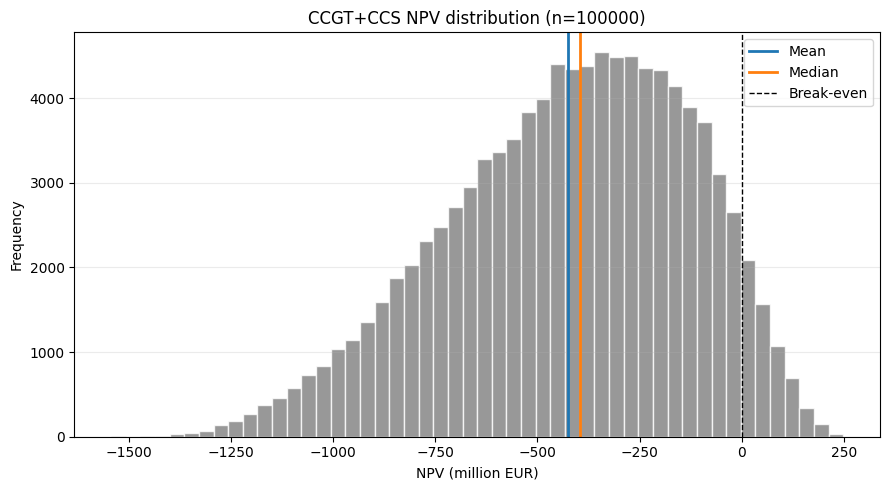

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## NPV per MWh histogram


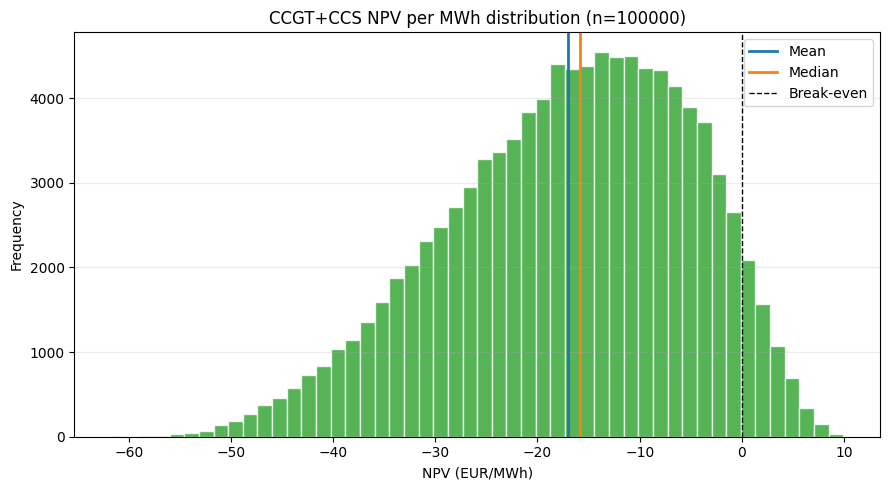

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"CCGT+CCS NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.618289
annual_variable_opex_eur      6.277900
annual_fuel_cost_eur         75.391874
annual_emissions_cost_eur     1.786418
annual_net_cash_flow_eur      0.995519
Name: Mean annual value, million EUR, dtype: float64